In [168]:
import scanpy as sc
import numpy as np
from importlib import reload

from gaussian_mixture_score_creation import *
import utils
reload(utils)

<module 'utils' from 'e:\\GitHub\\aggrigator_experiments\\spatial\\utils.py'>

In [169]:
config_path = 'E:/GitHub/aggrigator_experiments/spatial/spatial_configs/'
experiment = 0
normi = 'identity'  # or 'identity', 'logit', ' probit, 'arcsin-sqrt', 'quantile'
spatial = True
seed = 6

experiments = [
    'arctique_nuc',
    'arctique',
    'lidc',
    'lidc_tex',
    'ade20k',
    'gta']
experiment = experiments[experiment]
config = load_config(config_path=config_path+experiment+'.toml')
dataset_name = config['dataset']['dataset_name']
print(f"Loaded configuration for dataset: '{dataset_name}'")

paths = {
    'id_spatial': config['paths'].get('id_csv_path_spatial'),
    'ood_spatial': config['paths'].get('ood_csv_path_spatial'),
    'id_magnitude': config['paths'].get('id_csv_path_magnitude'),
    'ood_magnitude': config['paths'].get('ood_csv_path_magnitude')}
base_filename = config['paths'].get('base_filename', 'fingerprints')

Loaded configuration for dataset: 'arctique_inst'


# load data

In [170]:
id_spatial = load_spatial_fingerprints(paths['id_spatial'], base_filename)
ood_spatial = load_spatial_fingerprints(paths['ood_spatial'], base_filename)
id_magnitude = load_magnitude_fingerprints(paths['id_magnitude'], base_filename)
ood_magnitude = load_magnitude_fingerprints(paths['ood_magnitude'], base_filename)

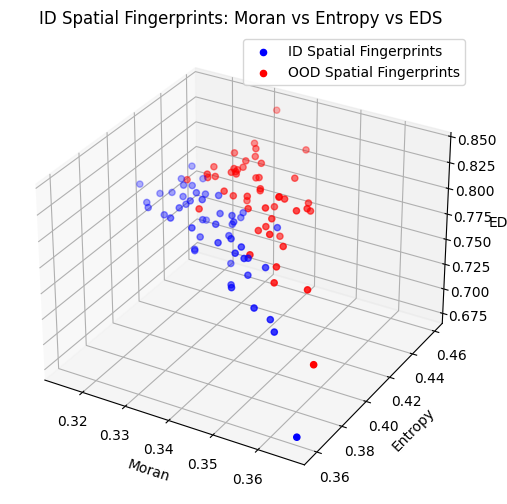

In [171]:
import matplotlib.pyplot as plt

# plot spatial fingerprints
plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')
ax.scatter(id_spatial['moran'], id_spatial['entropy'], id_spatial['eds'], label='ID Spatial Fingerprints', color='blue')
ax.scatter(ood_spatial['moran'], ood_spatial['entropy'], ood_spatial['eds'], label='OOD Spatial Fingerprints', color='red')
ax.set_xlabel('Moran')
ax.set_ylabel('Entropy')
ax.set_zlabel('EDS')
ax.legend()
ax.set_title('ID Spatial Fingerprints: Moran vs Entropy vs EDS')
plt.show()

In [172]:
# add id_spatial index name uq_map_name
id_spatial.index.name = 'uq_map_name'
id_magnitude.index = id_magnitude.index.astype('str')
id_spatial.index = id_spatial.index.astype('str')

# give a different name to ood spatial and ood magnitude
ood_spatial.index.name = 'uq_map_name'
ood_magnitude.index = ood_magnitude.index.astype('str')
ood_spatial.index = ood_spatial.index.astype('str')

ood_spatial.index = [f"ood_{idx}" for idx in ood_spatial.index]
ood_magnitude.index = [f"ood_{idx}" for idx in ood_magnitude.index]

# remove 0s before index
id_magnitude.index = id_magnitude.index.str.lstrip('0')
id_spatial.index = id_spatial.index.str.lstrip('0')

# join id_spatial and id_magnitude via the index uq_map_name
#id_magnitude.set_index('uq_map_name', inplace=True)
id_fingerprints = id_spatial.join(id_magnitude)
ood_fingerprints = ood_spatial.join(ood_magnitude)
all_fingerprints = pd.concat([id_fingerprints, ood_fingerprints], axis=0)

In [173]:
short_names = {
    'moran': 'moran',
    'entropy': 'entropy',
    'eds': 'EDS',
    'mean': 'mean',
    'above_threshold_mean_0.3': 'ATA .3',
    'above_threshold_mean_0.5': 'ATA .5',
    'above_threshold_mean_0.7': 'ATA .7',
    'above_threshold_mean_0.9': 'ATA .9',
    'above_threshold_mean_0.95': 'ATA .95',
    'above_quantile_mean_0.3': 'AQA .3',
    'above_quantile_mean_0.5': 'AQA .5',
    'above_quantile_mean_0.7': 'AQA .7',
    'above_quantile_mean_0.9': 'AQA .9',
    'above_quantile_mean_fg_ratio': 'AQA fg ratio',
    'patch_aggregation_10': 'PA 10',
    'patch_aggregation_20': 'PA 20',
    'patch_aggregation_40': 'PA 40',
    'patch_aggregation_80': 'PA 80',
    'patch_aggregation_100': 'PA 100',
    'class_mean_w_equal_weights_configurable': 'CM EW',
    'class_mean_weighted_by_occurrence_configurable': 'CM WO'
}

# Build adata object

In [174]:
adata = utils.setup_anndata_object(all_fingerprints)
adata = utils.create_fitting_split(adata, seed=seed, train_fraction=0.5)
adata = utils.apply_transformation(adata, transformation=normi, fitted_only=True)
    

PCA computed.
Neighbors computed.
Leiden clustering done.
UMAP computed.


h:\Users\Jannik\envs\aggro_spatial\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


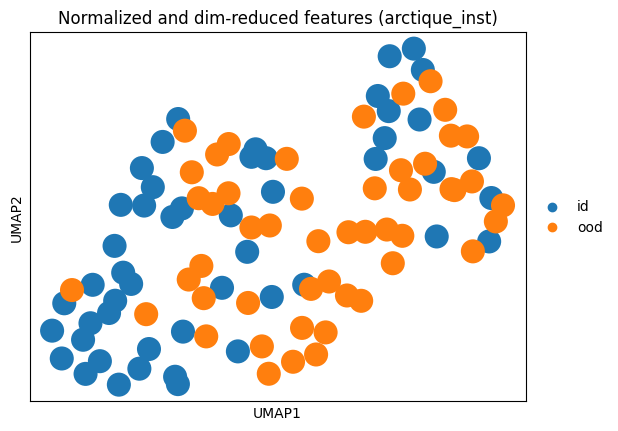

In [175]:
print("PCA computed.")
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_transformed')
print("Neighbors computed.")
sc.tl.leiden(adata, resolution=1.0)
print("Leiden clustering done.")
sc.tl.umap(adata)
print("UMAP computed.")

# plot umap
sc.pl.umap(adata, color=['sample_type'], title=f'Normalized and dim-reduced features ({dataset_name})', save=f'_{dataset_name}_spatial_fingerprints_umap.png')

21it [00:00, 26.85it/s]


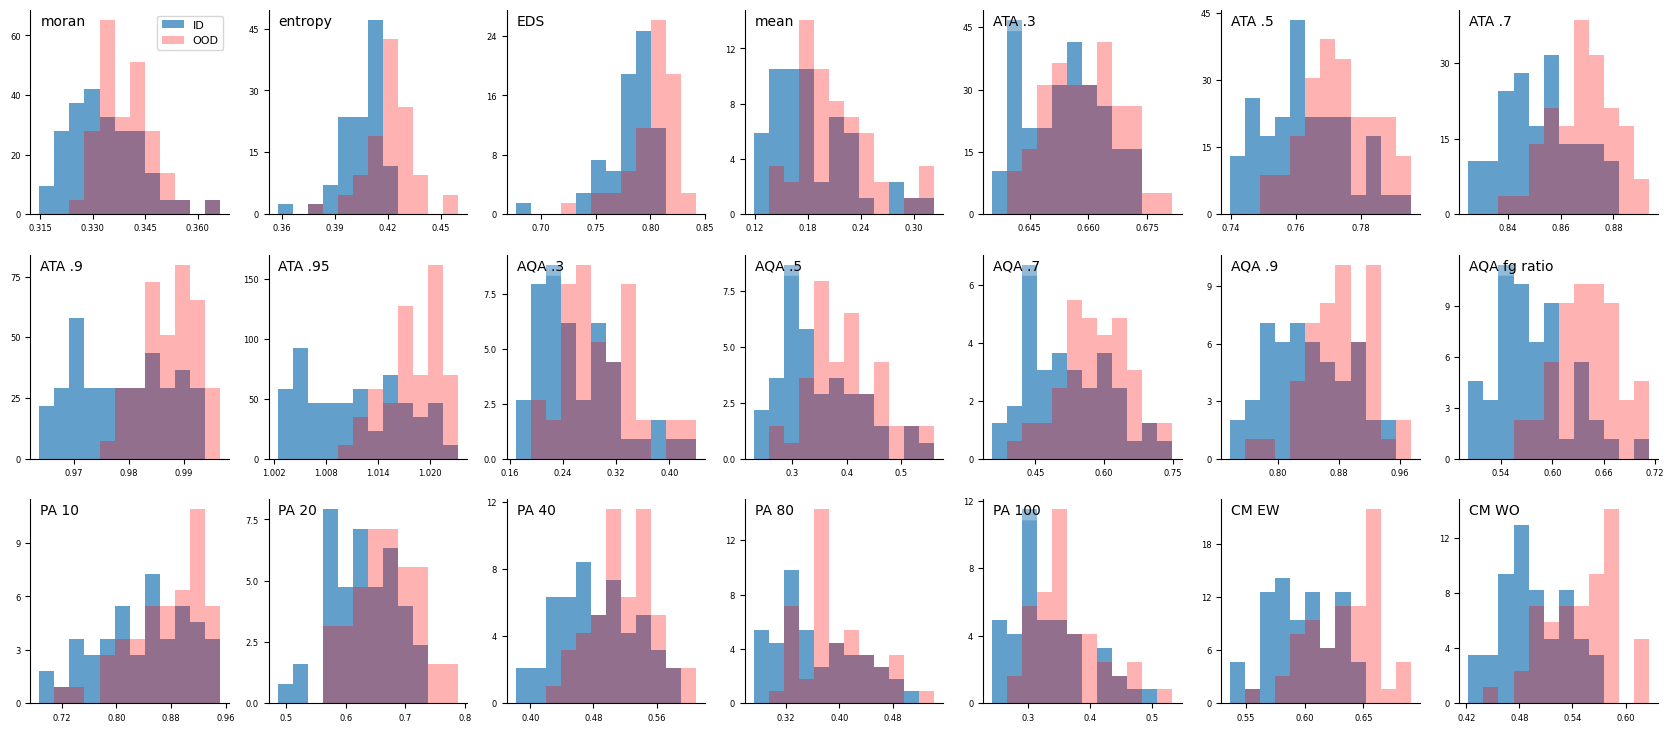

In [176]:
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm

n_vars = len(adata.var_names)
n_cols = 7  # number of columns per row
n_rows = int(np.ceil(n_vars / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axs = axs.flatten()

for i, var in tqdm(enumerate(adata.var_names)):
    ax = axs[i]
    col_idx = list(adata.var_names).index(var)
    id_data = adata[adata.obs['sample_type'] == 'id'].X[:, col_idx]
    ood_data = adata[adata.obs['sample_type'] == 'ood'].X[:, col_idx]
    all_data = np.concatenate([id_data, ood_data])
    n_points = len(all_data)
    n_bins = int(1.5*min(20, max(5, int(np.ceil(np.log2(n_points) + 1)))))
    bins = np.histogram_bin_edges(all_data, bins=n_bins)
    ax.hist(id_data, bins=bins, alpha=0.7, label='ID', density=True)
    ax.hist(ood_data, bins=bins, alpha=0.3, label='OOD', density=True, color='red')
    ax.text(
        0.05, 0.98, short_names[var.split('_{')[0]], transform=ax.transAxes, fontsize=10, ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.3, edgecolor='none', boxstyle='round,pad=0.2'))
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='both', which='major', labelsize=6)  # smaller tick font size

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

# save
plt.savefig(f'figures/fingerprints_histograms_{dataset_name}_{normi}.png', dpi=300, bbox_inches='tight')

# fit a GMM to the fingerprints

In [177]:
if spatial:
    selected_vars = ['moran', 'entropy', 'eds']
    adata = adata[:, selected_vars].copy()

    # # reduce X_pca
    adata.obsm['X_transformed'] = adata.X[:, :3]  # Assuming you want to keep the first 3 PCA components


--- Model Selection: Finding best GMM components ---


  0%|          | 0/10 [00:00<?, ?it/s]

Fitting GMM with 1 components and covariance type 'full'...


 10%|█         | 1/10 [00:00<00:02,  3.27it/s]

Fitting GMM with 2 components and covariance type 'full'...


...

 90%|█████████ | 9/10 [00:03<00:00,  2.78it/s]

Fitting GMM with 10 components and covariance type 'full'...


100%|██████████| 10/10 [00:03<00:00,  2.89it/s]

CONCLUSION: Optimal number of components is 1 with covariance type 'full' (lowest BIC).


Text(0.5, 0, 'Number of Components')

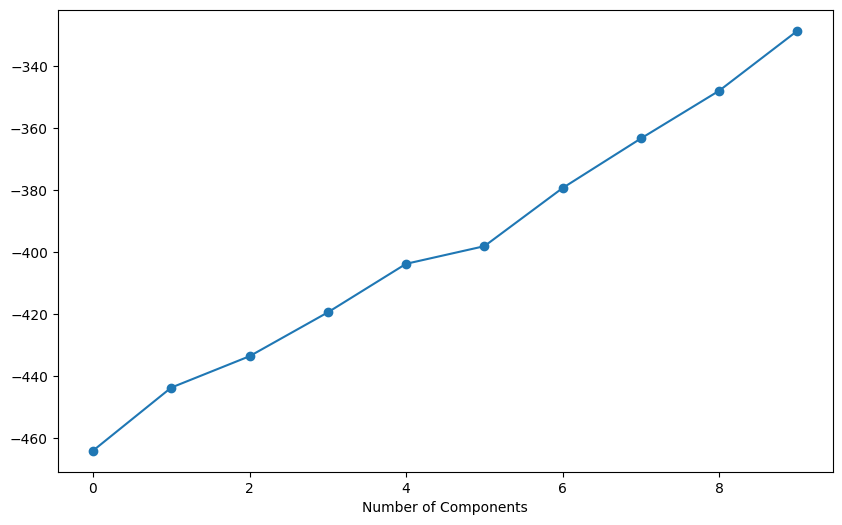

In [178]:
# select data as only fitted marked data points
data = adata[adata.obs['fitted'] == True].X

max_components = 10
param_grid = {
    "n_components": range(1, max_components + 1),
    "covariance_type":["full"],# ["spherical", "tied", "diag", "full"],
}
bic_scores = []
params_flat = []
print(f"\n--- Model Selection: Finding best GMM components ---")
for n in tqdm(param_grid['n_components']):
    for cov_type in param_grid['covariance_type']:
        print(f"Fitting GMM with {n} components and covariance type '{cov_type}'...")
        gmm = GaussianMixture(n_components=n, random_state=42, n_init=10, covariance_type=cov_type)
        gmm.fit(data)
        bic_scores.append(gmm.bic(data))
        params_flat.append((n, cov_type))
best_run = np.argmin(bic_scores)
best_components = params_flat[best_run][0]
best_cov_type = params_flat[best_run][1]
print(f"CONCLUSION: Optimal number of components is {best_components} with covariance type '{best_cov_type}' (lowest BIC).")

# plot BIC scores
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(bic_scores)),bic_scores, marker='o')
plt.xlabel('Number of Components')

h:\Users\Jannik\envs\aggro_spatial\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


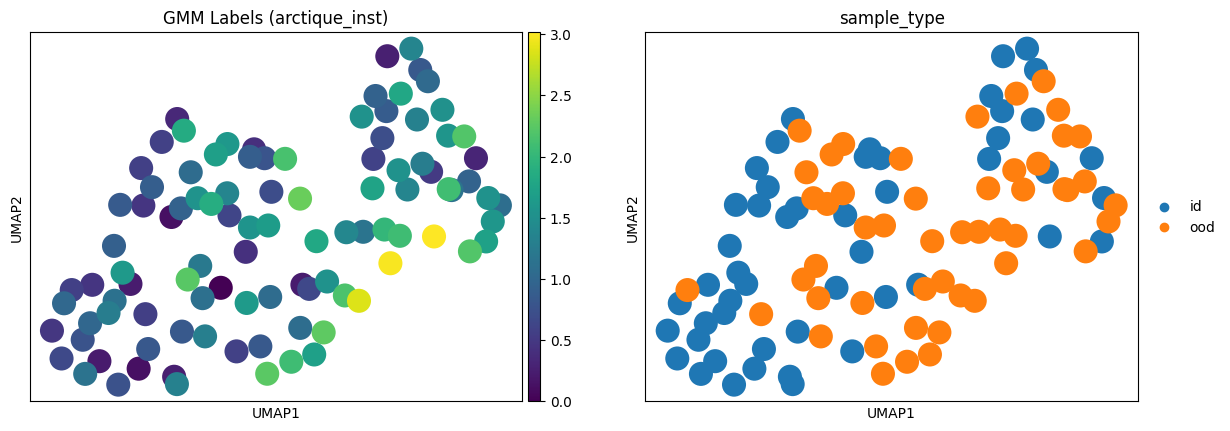

AUROC: 0.8728


In [179]:
# drop gmm labels if they exist in adata.obs
if 'gmm_label' in adata.obs.columns:
    adata.obs.drop(columns=['gmm_label'], inplace=True)

# fit gaussian mixture model to the PCA features
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=best_components, covariance_type=best_cov_type, random_state=42, n_init=10)
gmm.fit(data)

# predict the labels for all fingerprints using PCA features
id_log_likelihoods = gmm.score_samples(data)
max_density = np.exp(np.max(id_log_likelihoods))
log_p_values = gmm.score_samples(adata.obsm['X_transformed'])
scores_nll = -log_p_values
nll_min = -np.log(max_density + 1e-20)
ood_scores_nll_zero_floored = np.maximum(0, scores_nll - nll_min)
adata.obs['gmm_score'] = np.log1p(ood_scores_nll_zero_floored)

# plot the gmm labels on the umap
if 'gmm_label' in adata.var_names:
	adata.var.drop('gmm_label', inplace=True)
sc.pl.umap(adata, color=['gmm_score','sample_type'], title=f'GMM Labels ({dataset_name})')

# auroc
auroc = utils.compute_auroc(adata, 'gmm_score')
print(f"AUROC: {auroc:.4f}")

In [180]:
# display the results
input(f"AUROC {auroc} with GMM components: {best_components}, covariance type: '{best_cov_type}'")

''